## Filter Attacked texts using NLU

0. CONTRADICTION (противоречие)
1. NEUTRAL (нейтральный)
2. ENTAILMENT (логическое следствие)

In [1]:
folder = '/home/jovyan/shares/SR006.nfs2/zinkovich/zinkovich/ref-seg-text-break/experiments/metrics'

options = [
    'Gumbel-Input',
    'T5-unT5-Gumbel',
    'T5-unT5-Gumbel-approx',
    'jacobian-T5',
]
    
name = 'Gumbel-Input'

In [ ]:
import warnings
warnings.filterwarnings("ignore")

from transformers import AutoModelForSequenceClassification, AutoTokenizer
import torch
import pandas as pd
from tqdm import tqdm
from glob import glob
import os

model = AutoModelForSequenceClassification.from_pretrained("microsoft/deberta-large-mnli").cuda()
tokenizer = AutoTokenizer.from_pretrained("microsoft/deberta-large-mnli")

def process_row(row):
    def encode_input(t1, t2):
        input_text = f"[CLS] {t1} [SEP] {t2} [SEP]"
        return tokenizer.encode(input_text, padding=True, return_tensors='pt').to('cuda')
    
    encoded_inputs = [
        encode_input(row['orig_text'], row['adv_text']),
        encode_input(row['adv_text'], row['orig_text'])
    ]
    with torch.no_grad():
        logits = [model(encoded)['logits'] for encoded in encoded_inputs]
        labels = [torch.argmax(logit, dim=1).item() for logit in logits]
    return all(label != 0 for label in labels)


path = os.path.join(folder, name)
csv_files = glob(os.path.join(path, "results_sample*.csv"))
filtered_dfs = []
n_empty = 0

for file_path in tqdm(csv_files):
    df = pd.read_csv(file_path)
    
    df_unique = df[df['iteration'] != 0].drop_duplicates(subset='adv_text')
    orig_iou = df.loc[df['iteration'] == 0, 'iou'].iloc[0]
    df_unique['orig_iou'] = orig_iou

    df_filtered = df_unique[df_unique['iou'] < orig_iou].copy()

    if df_filtered.empty: 
        n_empty += 1
        continue
    
    df_filtered.loc[:, 'sem_equiv'] = df_filtered.apply(process_row, axis=1)
    df_filtered = df_filtered[df_filtered['sem_equiv']].nsmallest(10, 'iou')
    filtered_dfs.append(df_filtered)
    
print(f"Empty dataFrames = {n_empty}/{len(csv_files)}")


In [ ]:
final_df = pd.concat(filtered_dfs, ignore_index=True)
final_df.to_csv(os.path.join(path, "final_filtered_results.csv"), index=False)

## Concatenate all results in One table

In [12]:
files_to_unite = [
    'Gumbel-Input',
    # 'T5-unT5-Gumbel',
    # 'T5-unT5-Gumbel-approx',
    # 'jacobian-T5',
]

In [ ]:
csv_files = glob(os.path.join(path, "final_filtered_results.csv"))
all_data = []

for method_name in files_to_unite:
    df = pd.read_csv(os.path.join(folder, method_name))
    grouped = df.groupby('sample_idx')
    
    for sample_idx, group in grouped:
        unique_adv_texts = group[group['iteration'] > 0].drop_duplicates(subset=['adv_text'])
        orig_iou = group['orig_iou'].iloc[0]
        
        for idx, row in unique_adv_texts.iterrows():
            all_data.append({
                'orig_text': row['orig_text'],
                'method_name': method_name,
                'adv_text': row['adv_text'],
                'orig_iou': orig_iou,
                'adv_iou': row['iou'],
                'cos_sim': row['cos_sim']
            })

New table saved to consolidated_results.csv


In [ ]:
final_df = pd.DataFrame(all_data).sort_values(by=['orig_text', 'method_name']).reset_index(drop=True)
final_df.to_csv(f"{folder}/consolidated_results.csv")

## Visualizations and Analysis

### Analysis

In [14]:
path = os.path.join(folder, name)
df = pd.read_csv(os.path.join(path, "final_filtered_results.csv"))

In [16]:
df.head()

,sample_idx,iteration,adv_text,orig_text,iou,cos_sim,orig_iou,sem_equiv
0,100,240,"In outdoor recreational activities, people can...","In outdoor recreational activities, people can...",0.974849,0.977339,0.97723,True
1,100,220,"In outdoor recreational activities, people can...","In outdoor recreational activities, people can...",0.974884,0.992959,0.97723,True
2,100,250,"In thedoor recreational activities, people can...","In outdoor recreational activities, people can...",0.974895,0.949771,0.97723,True
3,100,190,"In thedoor recreational activities, people can...","In outdoor recreational activities, people can...",0.974919,0.958390,0.97723,True
4,100,230,"In thedoor recreational activities, people can...","In outdoor recreational activities, people can...",0.975303,0.975726,0.97723,True


#### IoU

In [25]:
print(f'Original IoU \n \
    Mean = {df.groupby('sample_idx')['orig_iou'].mean().mean():.2f} \n \
    Max  = {df.groupby('sample_idx')['orig_iou'].mean().max():.2f} \n \
    Min  = {df.groupby('sample_idx')['orig_iou'].mean().min():.2f} \n \
    ')


Original IoU 
     Mean = 0.84 
     Max  = 1.00 
     Min  = 0.06 
     


In [28]:
print(f'Adversarial IoU \n \
    Mean = {df.groupby('sample_idx')['iou'].mean().mean():.2f} \n \
    Max  = {df.groupby('sample_idx')['iou'].mean().max():.2f} \n \
    Min  = {df.groupby('sample_idx')['iou'].mean().min():.2f} \n \
    ')


Adversarial IoU 
     Mean = 0.64 
     Max  = 1.00 
     Min  = 0.00 
     


#### Cosine Similarity

In [29]:
print(f'Adversarial Cos Sim \n \
    Mean = {df.groupby('sample_idx')['cos_sim'].mean().mean():.2f} \n \
    Max  = {df.groupby('sample_idx')['cos_sim'].mean().max():.2f} \n \
    Min  = {df.groupby('sample_idx')['cos_sim'].mean().min():.2f} \n \
    ')


Adversarial Cos Sim 
     Mean = 0.89 
     Max  = 0.98 
     Min  = 0.52 
     


### Visualizations

#### Distributions

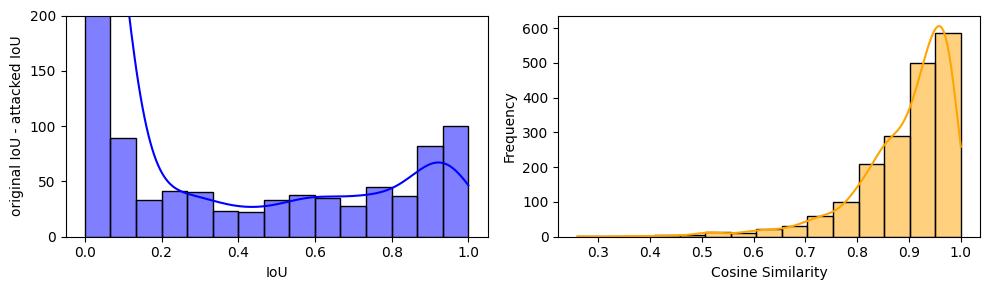

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 3))

plt.subplot(1, 2, 1)
sns.histplot(df['orig_iou'] - df['iou'], bins=15, kde=True, color='blue')
plt.xlabel('IoU')
plt.ylabel('original IoU - attacked IoU')
plt.ylim(0, 200)

plt.subplot(1, 2, 2)
sns.histplot(df['cos_sim'], bins=15, kde=True, color='orange')
plt.xlabel('Cosine Similarity')
plt.ylabel('Frequency')

plt.tight_layout()
#plt.savefig('distrub', dpi=300)
plt.show()

#### How many points have successfully attacked Text

sample_idx
1      0.989767
3      0.082089
4      0.095022
5      0.000258
6      0.921316
         ...   
195    0.003173
196    0.390661
197    0.003503
198    0.038705
199    0.002048
Length: 197, dtype: float64

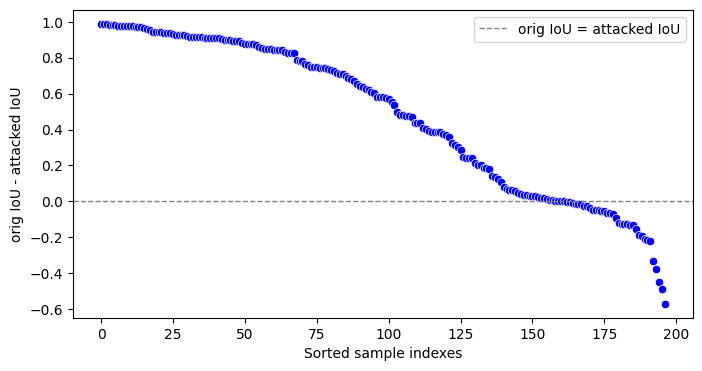

In [59]:
import matplotlib.pyplot as plt
import seaborn as sns

min_iou = df.groupby('sample_idx')['orig_iou'].mean() - df.groupby('sample_idx')['iou'].min()

df['iou_diff'] = df['orig_iou'] - min_iou
df_sorted = df.sort_values(by='iou_diff', ascending=False)

plt.figure(figsize=(8, 4))
sns.scatterplot(data=df_sorted, x=range(len(df_sorted)), y='iou_diff', color='blue')

plt.axhline(y=0, color='grey', linestyle='--', linewidth=1, label='orig IoU = attacked IoU')

plt.xlabel('Sorted sample indexes')
plt.ylabel('orig IoU - attacked IoU')
plt.legend()

plt.show()


#### Hists

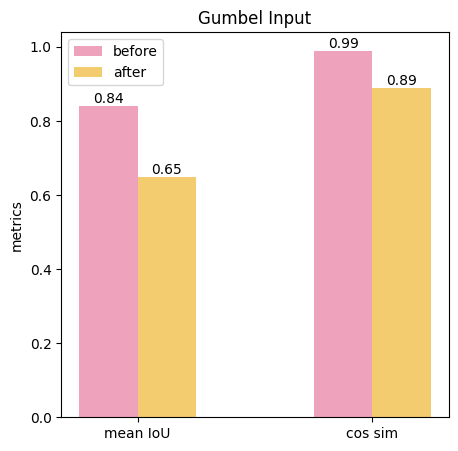

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

methods = ['mean IoU', 'cos sim']
f1_before = [0.84, 0.99] 
f1_after = [0.65, 0.89] 

num_methods = len(methods)

bar_width = 0.25
x = np.arange(num_methods)

fig, ax = plt.subplots(figsize=(5, 5))

before_color = '#E87B9F'
after_color = '#EDB732'
alpha_value = 0.7

bars1 = ax.bar(x - bar_width / 2, f1_before, bar_width, color=before_color, label='before', alpha=alpha_value)
bars2 = ax.bar(x + bar_width / 2, f1_after, bar_width, color=after_color, label='after', alpha=alpha_value)

for bar in bars1:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, yval, f'{yval:.2f}', ha='center', va='bottom')

for bar in bars2:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, yval, f'{yval:.2f}', ha='center', va='bottom')

ax.set_ylabel('metrics')
ax.set_xticks(x)
ax.set_xticklabels(methods)
ax.set_title('Gumbel Input')
ax.legend()

plt.savefig("plots.png", format="png", dpi=300, bbox_inches="tight")
plt.show()


### Other

In [2]:
import pandas as pd
import os

df = pd.read_csv(os.path.join(folder, name, 'final_filtered_results.csv'))

In [7]:
df[df['sample_idx'] == 10]

,sample_idx,iteration,adv_text,orig_text,iou,cos_sim,orig_iou,sem_equiv
731,10,160,"When eating scrambled eggs for breakfast, the ...","When eating scrambled eggs for breakfast, peop...",0.006319,0.902914,0.485503,True
732,10,180,"When eating scrambled eggs for breakfast, peop...","When eating scrambled eggs for breakfast, peop...",0.006335,0.981522,0.485503,True
733,10,180,"When eating scrambled eggs for breakfast, peop...","When eating scrambled eggs for breakfast, peop...",0.006377,0.985320,0.485503,True
734,10,180,"When eating scrambled eggs for breakfast, peop...","When eating scrambled eggs for breakfast, peop...",0.006433,0.979906,0.485503,True
735,10,270,"When eating scrambled eggs for breakfast, peop...","When eating scrambled eggs for breakfast, peop...",0.482586,0.965604,0.485503,True
736,10,250,"When eating scrambled c for breakfast, people ...","When eating scrambled eggs for breakfast, peop...",0.484226,0.977462,0.485503,True
737,10,140,"When eating thatrambled eggs for breakfast, pe...","When eating scrambled eggs for breakfast, peop...",0.484342,0.988954,0.485503,True
738,10,260,"When eating therambled eggs for breakfast, peo...","When eating scrambled eggs for breakfast, peop...",0.484713,0.982904,0.485503,True
739,10,250,"When eating therambled eggs for breakfast, peo...","When eating scrambled eggs for breakfast, peop...",0.484715,0.972870,0.485503,True
740,10,240,"When eating scrambled eggs, breakfast, it ofte...","When eating scrambled eggs for breakfast, peop...",0.484922,0.966500,0.485503,True
